<a href="https://colab.research.google.com/github/julimarpoliveira2902/Financial-Analysis-PySpark/blob/main/An%C3%A1lise_de_Performance_Tech_(AAPL%2C_MSFT%2C_GOOGL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Instalação das bibliotecas necessárias
!pip install yfinance pyspark -q

# 2. Configuração do ambiente Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("AnaliseFinanceiraBairesDev").getOrCreate()

print("Ambiente Spark configurado com sucesso!")

Ambiente Spark configurado com sucesso!


In [3]:
import yfinance as yf
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Configuração do Spark (Caso esteja no Colab)
spark = SparkSession.builder.master("local[*]").appName("AnaliseFinanceiraBairesDev").getOrCreate()

# 2. Coleta de Dados - Ajustado para usar 'Close' em vez de 'Adj Close'
tickers = ['AAPL', 'MSFT', 'GOOGL']
# Buscamos os dados e selecionamos apenas a coluna 'Close'
df_pd = yf.download(tickers, start="2024-01-01", end="2026-03-01")['Close'].reset_index()

# 3. Transformação: Pandas para Spark (Formato 'Long' para análise de séries temporais)
df_melted = df_pd.melt(id_vars=['Date'], var_name='Ticker', value_name='Price')
df_spark = spark.createDataFrame(df_melted)

# 4. Cálculo de Métricas Financeiras Avançadas com Spark Window Functions
# Definimos a 'janela' por Ticker e data
windowSpec = Window.partitionBy("Ticker").orderBy("Date")

# Média Móvel de 20 dias (SMA20)
windowSMA = windowSpec.rowsBetween(-19, 0)
df_spark = df_spark.withColumn("SMA_20", F.avg("Price").over(windowSMA))

# Cálculo de Retorno Diário (Variação %)
df_spark = df_spark.withColumn("Prev_Price", F.lag("Price").over(windowSpec))
df_spark = df_spark.withColumn("Daily_Return",
                               (F.col("Price") - F.col("Prev_Price")) / F.col("Prev_Price"))

# 5. Exibição dos Resultados
df_spark.filter(F.col("Daily_Return").isNotNull()).show(15)

print("Análise processada com sucesso via PySpark!")

/tmp/ipykernel_194/1299577880.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_pd = yf.download(tickers, start="2024-01-01", end="2026-03-01")['Close'].reset_index()
[*********************100%***********************]  3 of 3 completed


+-------------------+------+------------------+------------------+------------------+--------------------+
|               Date|Ticker|             Price|            SMA_20|        Prev_Price|        Daily_Return|
+-------------------+------+------------------+------------------+------------------+--------------------+
|2024-01-03 00:00:00|  AAPL|182.35560607910156|183.04347229003906|183.73133850097656|-0.00748773961534...|
|2024-01-04 00:00:00|  AAPL|180.03965759277344|182.04220072428384|182.35560607910156|-0.01270017706679...|
|2024-01-05 00:00:00|  AAPL|179.31715393066406| 181.3609390258789|180.03965759277344|-0.00401302508441...|
|2024-01-08 00:00:00|  AAPL|183.65213012695312|181.81917724609374|179.31715393066406| 0.02417491077270417|
|2024-01-09 00:00:00|  AAPL|183.23643493652344|182.05538686116537|183.65213012695312|-0.00226349234360...|
|2024-01-10 00:00:00|  AAPL|  184.275634765625|182.37256513323103|183.23643493652344|0.005671360226264831|
|2024-01-11 00:00:00|  AAPL|183.68179

In [4]:
# 1. Calculando a Volatilidade (Desvio Padrão Móvel de 21 dias - 1 mês comercial)
windowVol = Window.partitionBy("Ticker").orderBy("Date").rowsBetween(-20, 0)

df_spark = df_spark.withColumn("Volatility_21d", F.stddev("Daily_Return").over(windowVol))

# 2. Vamos converter de volta para Pandas apenas para a Visualização Final
df_final = df_spark.toPandas()

# Limpando valores nulos gerados pelos cálculos de janela
df_final.dropna(inplace=True)

print("Cálculo de Volatilidade concluído!")
df_final.head()

Cálculo de Volatilidade concluído!


,Date,Ticker,Price,SMA_20,Prev_Price,Daily_Return,Volatility_21d
2,2024-01-04,AAPL,180.039658,182.042201,182.355606,-0.012700,0.003686
3,2024-01-05,AAPL,179.317154,181.360939,180.039658,-0.004013,0.004372
4,2024-01-08,AAPL,183.652130,181.819177,179.317154,0.024175,0.016512
5,2024-01-09,AAPL,183.236435,182.055387,183.652130,-0.002263,0.014335
6,2024-01-10,AAPL,184.275635,182.372565,183.236435,0.005671,0.013063


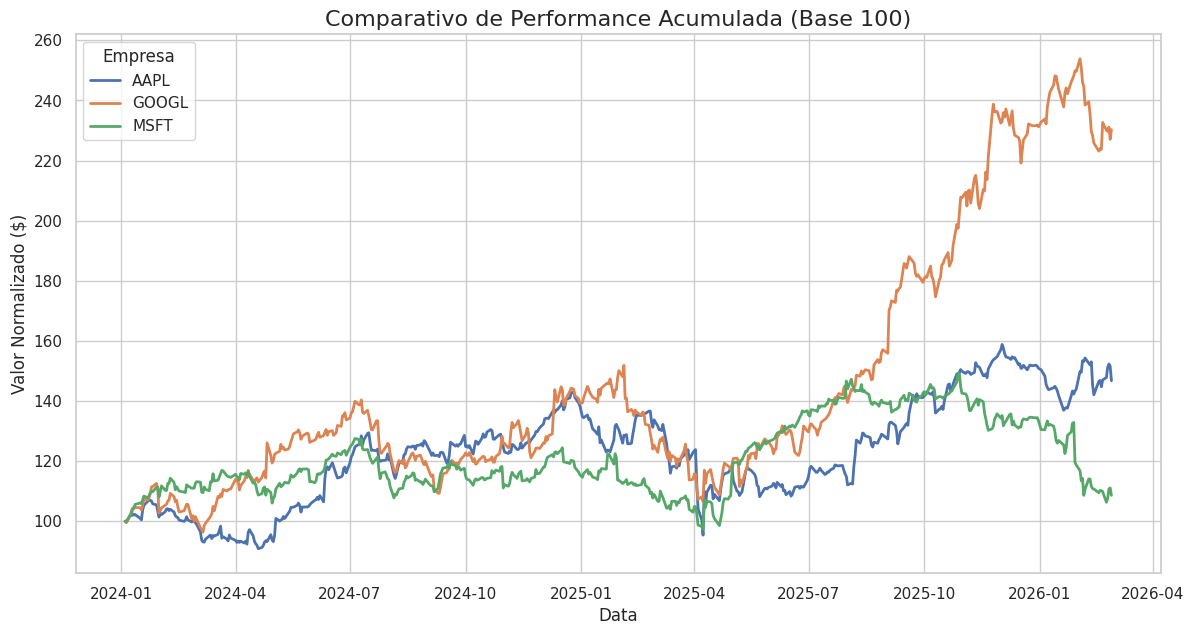

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Criando o gráfico de Preço Normalizado (Base 100) para comparação justa
df_final['Normalized_Price'] = df_final.groupby('Ticker')['Price'].transform(lambda x: (x / x.iloc[0]) * 100)

sns.lineplot(data=df_final, x='Date', y='Normalized_Price', hue='Ticker', linewidth=2)

plt.title('Comparativo de Performance Acumulada (Base 100)', fontsize=16)
plt.ylabel('Valor Normalizado ($)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.legend(title='Empresa')
plt.show()